### Default Linear Regression


=== PER FOLD RESULTS TABLE ===
   Fold  Train_R2    Val_R2  Train_RMSE  Val_RMSE  Train_MAE   Val_MAE
0     1  0.688528  0.673732    0.201082  0.207465   0.157295  0.160915
1     2  0.688371  0.677750    0.201384  0.205135   0.157121  0.160274
2     3  0.690597  0.667159    0.200237  0.210257   0.156241  0.163248
3     4  0.692595  0.656700    0.201291  0.206293   0.157533  0.159751
4     5  0.686303  0.686515    0.201821  0.203285   0.157537  0.158736

LINEAR REGRESSION (DEFAULT) - 5-FOLD CV (LOG SCALE)
Metric              Train     Validation            Gap
----------------------------------------------------------------------
R²                 0.6893         0.6724         0.0169
RMSE               0.2012         0.2065               
MAE                0.1571         0.1606               

LINEAR REGRESSION (DEFAULT) - TRAIN & TEST (ORIGINAL SCALE)
Metric              Train           Test
----------------------------------------------------------------------
R²                 0.

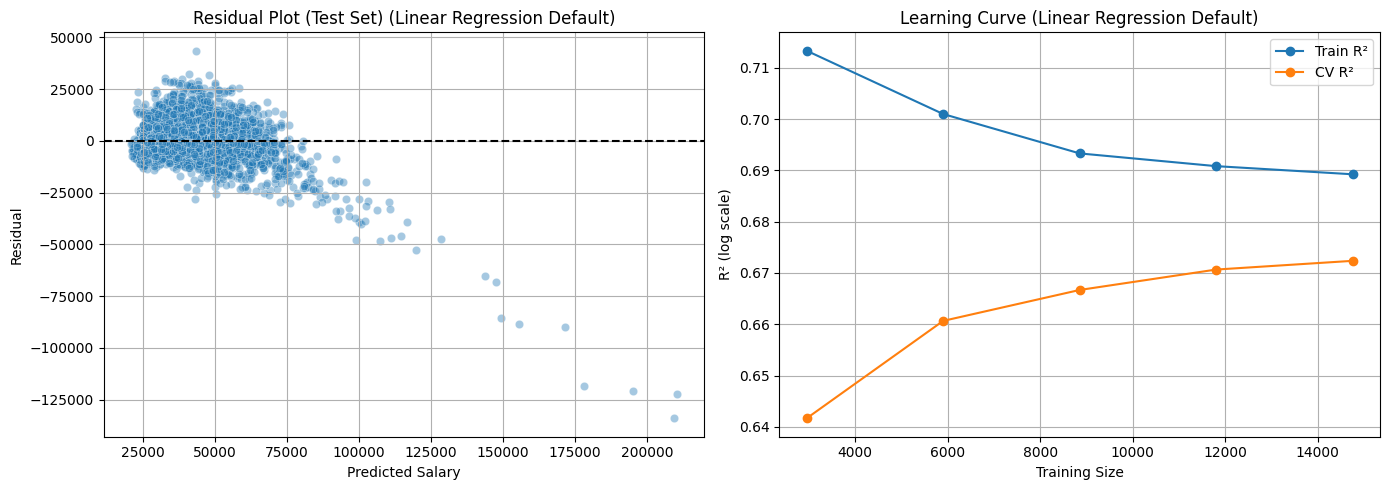

In [ ]:
import random
import warnings
import torch
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Machine Learning Models
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve


# REPRODUCIBILITY
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

warnings.filterwarnings("ignore")

# LOAD DATA
df = pd.read_csv(
    "../Unified_Resume_Salary_Dataset.csv"
)

with open("../master_vocab.pkl", "rb") as f:
    master_vocab = pickle.load(f)

train_idx = np.load("../train_idx.npy")
test_idx  = np.load("../test_idx.npy")

X_text = df["Aligned_Text"]
y = df["Log_Salary"]

X_train = X_text.iloc[train_idx]
X_test  = X_text.iloc[test_idx]
y_train = y.iloc[train_idx].values
y_test  = y.iloc[test_idx].values

# PIPELINE
tfidf_config = dict(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*',
    norm=None,
    binary=True,
    min_df=5
)

model = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_config)),
    ("model", LinearRegression())
])

# CROSS VALIDATION SETUP
cv = KFold(n_splits=5, shuffle=True, random_state=seed)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

# RUN CROSS VALIDATION
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# PER-FOLD RESULTS TABLE
fold_df = pd.DataFrame({
    "Fold": np.arange(1, cv.get_n_splits() + 1),

    "Train_R2": cv_results["train_r2"],
    "Val_R2": cv_results["test_r2"],

    "Train_RMSE": -cv_results["train_rmse"],
    "Val_RMSE": -cv_results["test_rmse"],

    "Train_MAE": -cv_results["train_mae"],
    "Val_MAE": -cv_results["test_mae"]
})

print("\n=== PER FOLD RESULTS TABLE ===")
print(fold_df)

# METRICS (LOG SCALE - CV ONLY)
cv_train_r2 = np.mean(cv_results["train_r2"])
cv_val_r2   = np.mean(cv_results["test_r2"])

cv_train_rmse = -np.mean(cv_results["train_rmse"])
cv_val_rmse   = -np.mean(cv_results["test_rmse"])

cv_train_mae = -np.mean(cv_results["train_mae"])
cv_val_mae   = -np.mean(cv_results["test_mae"])

gap = cv_train_r2 - cv_val_r2

# PRINT PER MODEL SUMMARY
print("\n" + "="*70)
print(f"{'LINEAR REGRESSION (DEFAULT) - 5-FOLD CV (LOG SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Validation':>15}{'Gap':>15}")
print("-"*70)
print(f"{'R²':<10}{cv_train_r2:>15.4f}{cv_val_r2:>15.4f}{gap:>15.4f}")
print(f"{'RMSE':<10}{cv_train_rmse:>15.4f}{cv_val_rmse:>15.4f}{'':>15}")
print(f"{'MAE':<10}{cv_train_mae:>15.4f}{cv_val_mae:>15.4f}{'':>15}")
print("="*70)

# TRAIN FINAL MODEL ON FULL TRAIN SET
model.fit(X_train, y_train)

# Predictions (LOG SCALE)
train_pred_log = model.predict(X_train)
test_pred_log  = model.predict(X_test)

# INVERSE TRANSFORM (BACK TO ORIGINAL SALARY)
train_pred = np.expm1(train_pred_log)
test_pred  = np.expm1(test_pred_log)

y_train_actual = np.expm1(y_train)
y_test_actual  = np.expm1(y_test)

# METRICS (ORIGINAL SCALE)
train_r2_orig = r2_score(y_train_actual, train_pred)
test_r2_orig  = r2_score(y_test_actual, test_pred)

train_rmse_orig = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse_orig  = np.sqrt(mean_squared_error(y_test_actual, test_pred))

train_mae_orig = mean_absolute_error(y_train_actual, train_pred)
test_mae_orig  = mean_absolute_error(y_test_actual, test_pred)

# PRINT
print("\n" + "="*70)
print(f"{'LINEAR REGRESSION (DEFAULT) - TRAIN & TEST (ORIGINAL SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Test':>15}")
print("-"*70)
print(f"{'R²':<10}{train_r2_orig:>15.4f}{test_r2_orig:>15.4f}")
print(f"{'RMSE':<10}{train_rmse_orig:>15,.2f}{test_rmse_orig:>15,.2f}")
print(f"{'MAE':<10}{train_mae_orig:>15,.2f}{test_mae_orig:>15,.2f}")
print("="*70)


# PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Residual Plot (ORIGINAL SCALE) ---
residuals = y_test_actual - test_pred

sns.scatterplot(
    x=test_pred,
    y=residuals,
    alpha=0.4,
    ax=axes[0]
)

axes[0].axhline(0, linestyle='--', color='black')
axes[0].grid(True)
axes[0].set_title("Residual Plot (Test Set) (Linear Regression Default)")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual")

# --- Learning Curve (LOG SCALE) ---
train_sizes, train_scores, val_scores = learning_curve(
    model,                 
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

axes[1].plot(
    train_sizes,
    np.mean(train_scores, axis=1),
    marker='o',
    label="Train R²"
)

axes[1].plot(
    train_sizes,
    np.mean(val_scores, axis=1),
    marker='o',
    label="CV R²"
)

axes[1].grid(True)
axes[1].set_title("Learning Curve (Linear Regression Default)")
axes[1].set_xlabel("Training Size")
axes[1].set_ylabel("R² (log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()